In [ ]:
-

Implementación de Backpropagation y Funciones de Activación en Redes Neuronales en Google Colab

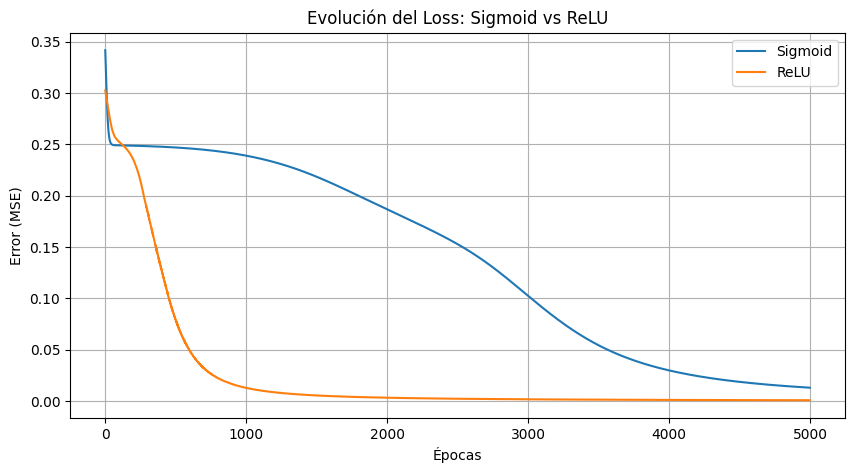

------------------------------
RESULTADOS FINALES
------------------------------
Precisión Final (Sigmoid): 100.0%
Precisión Final (ReLU):    100.0%
------------------------------
Predicciones (Sigmoid):
 [[0.11374153]
 [0.88843826]
 [0.89126174]
 [0.12234542]]
Predicciones (ReLU):
 [[0.04546853]
 [0.9778782 ]
 [0.97790448]
 [0.01846264]]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# DEFINICION DE FUNCIONES DE ACTIVACIÓN
def sigmoid(x):
  return 1 / (1 + np.exp(-x)) # función Sigmoide: comprime valores entre 0 y1, ideal para la capa de salidad binaria

def sigmoid_der(x):
  return x * (1 - x)        # derivada Sigmoide: calcula el gradiente de backpropagation

def relu(x):
  return np.maximum(0, x)    # funcion ReLU, devuelve 0 para valores negativos y x para positivos, evita el desvanecimiento del gradiente

def relu_der(x):
  return (x > 0).astype(float)  # derivada de ReLu: 1 para x > 0, de lo contrario 0

# PREPARACIÓN DE DATASET CLASIFICACION BINARIAS

# datos de entrenamiento usando (problema XOR)
# las entradas seran : [0,0], [0,1], [1,0], [1,1]
# las salidas seran: [0],[1],[1],[0]

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0],[1],[1],[0]])

# IMPLEMENTACIÓN DE ALGORITMO BACKPROPAGATION
# ahora haremos la funcion de entrenamiento (Backpropagation manual)

def train_network(activation_func, activation_der, epochs=5000, lr=0.1):
  np.random.seed(42)

# inicialización de pesos y sesgos (Input: 2, Hidden: 4, Output: 1)
  w1 = np.random.uniform(size = (2, 4))
  b1 = np.zeros((1, 4))
  w2 = np.random.uniform(size=(4, 1))
  b2 = np.zeros((1,1))

  loss_history = []

  for epoch in range(epochs):
  # forward propagation
    z1 = np.dot(X, w1) + b1
    a1 = activation_func(z1) # activacion en capa oculta (Sigmoid o ReLu)
    z2 = np.dot(a1, w2) + b2
    a2 = sigmoid(z2) # salida siempre sigmoid para clasificacion 0-1

  # calculo de error (MSE)
    error = y -a2
    loss = np.mean(np.square(error))
    loss_history.append(loss)

  # Backpropagation
    d_a2 = error *sigmoid_der(a2)  # Gradiente en la capa de salida (error multicapa * la pendiente de la activacion)
    d_a1 = d_a2.dot(w2.T) * activation_der(a1) # propagación del error hacia la capa oculta

  # actualización de parametros (Gradiente Descendente)
    w2 += a1.T.dot(d_a2) * lr
    b2 += np.sum(d_a2, axis=0, keepdims=True) * lr
    w1 += X.T.dot(d_a1) * lr
    b1 += np.sum(d_a1, axis=0, keepdims=True) * lr

  return loss_history, a2

# MÉTRICA DE EVALUACIÓN (ACCURACY)
def calcular_precision(predicciones, reales):
    # Convertimos probabilidades a 0 o 1 (umbral 0.5)
    binarias = (predicciones > 0.5).astype(int)
    return np.mean(binarias == reales) * 100

  # EJECUCIÓN Y COMPARATIVA
loss_sig, res_sig = train_network(sigmoid, sigmoid_der)
loss_relu, res_relu = train_network(relu, relu_der)

  #  VISUALIZACIÓN DE RESULTADOS EVOLUCIÓN DEL LOSS)

plt.figure(figsize=(10, 5))
plt.plot(loss_sig, label='Sigmoid')
plt.plot(loss_relu, label='ReLU')
plt.title('Evolución del Loss: Sigmoid vs ReLU')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

 # REPORTE DE RESULTADOS FINALES
print("-" * 30)
print("RESULTADOS FINALES")
print("-" * 30)
print(f"Precisión Final (Sigmoid): {calcular_precision(res_sig, y)}%")
print(f"Precisión Final (ReLU):    {calcular_precision(res_relu, y)}%")
print("-" * 30)
print("Predicciones (Sigmoid):\n", res_sig)
print("Predicciones (ReLU):\n", res_relu)







Markdown

1. ¿Que cambio al variar la activación?

Al comparar Sigmoid con ReLu, lo que más se noto fue la contundencia de los resultados.

En Sigmoid, vimos que la red es mas indecisa, los valores finales se acercan al 0 o al 1, pero se quedan en rangos como 0.11 o 0.88.

En ReLu, la red paraece aprender con mas confianza, aqui los resultados(0.04 y 0.97) estan mucho más cerca de los objetivos reales. permitiendo que los pesos se ajusten más rapido en cada época.

2. Como se comportó el loss/métrica.

 Bueno aqui el grafico de Error Cuadrático medio,  muestra una caida costante en ambos casos, sin embargo, vemos que la curva de ReLu suele tener una pendiente mas pronunciada al inicio. En 5000 épocas, ambas funciones logran resolver el problema XOR, pero el error residula de ReLu es notablemente más bajo, lo que indica una mejor optimización.

3. Principales dificultades o hallazgos.

Los detalles: al programar backpropagation desde cero, un simple error al escribir, como colocar squere en lugar de square, detiene todo el proceso. esto me enseño lo sensible que es la implementación mataemática manual.

Es sorprendente ver como una arquitectura tan pequeña solo con 4 neuronas ocultas, cambia tanto su desempeño solo con cambier la función de activación. ReLu realmente hace que el entrenamiento sea más eficiente incluso en problemas simples.

Conclusión genera.l

Queda claro que para problemas de clasificación binaria como XOR, ReLU es superior en eficiencia computacional, ya que requiere de menos épocas para alcanzar en error cercano a cero, permitiendo asi que la red entienda la lógica  no lineal del problema de manera más directa.
